

# Parametrised Quantum Circuits for Reinforcement Learning

In [ ]:
!pip install tensorflow==2.15.0
!pip install tensorflow-quantum==0.7.3
!pip install gym==0.18.0
!pip install gym-anytrading
!pip install gym-trading-env pandas-datareader arrow
#!pip install --upgrade gym==0.21.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 32.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.8/598.8 kB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 58.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.0
    Uninstalling sympy-1.13.0:
      Successfully uninstalled sympy-1.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.3.0+cu121 requires nvidia-cublas-cu12==12.1.3.1; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.0+cu121 requires nvidia-cuda-cupti-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.0+cu121 requires nvidia-cuda-nvrtc-cu12==12.1.105; pla

Quantum variational circuit is used as a function approximator to estimate Q-values for each state-action pair. Circuit is constructed using ReUploadingPQC layer, which applies a parameterised quantum circuit with re-uploading of the input data at each layer. The input to quantum circuit is the state observation, and the output is the Q-values for each action.

**Sharpe Ratio**

/usr/local/lib/python3.10/dist-packages/pandas_datareader/compat/__init__.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_VERSION = LooseVersion(pd.__version__)


Episode 0, Total Reward: -2.0033970897764988, Epsilon: 0.99
Episode 100, Total Reward: 0.11188306612043863, Epsilon: 0.60
Episode 200, Total Reward: -1.5279363767627598, Epsilon: 0.37
Episode 300, Total Reward: -1.4985916274059086, Epsilon: 0.22
Episode 400, Total Reward: 8.073350243262375, Epsilon: 0.13
Episode 500, Total Reward: 11.985108037108398, Epsilon: 0.08
Episode 600, Total Reward: 13.798051828703015, Epsilon: 0.05
Episode 700, Total Reward: 15.324371670761222, Epsilon: 0.03
Episode 800, Total Reward: 15.84618738557286, Epsilon: 0.02
Episode 900, Total Reward: 15.852881591561378, Epsilon: 0.01


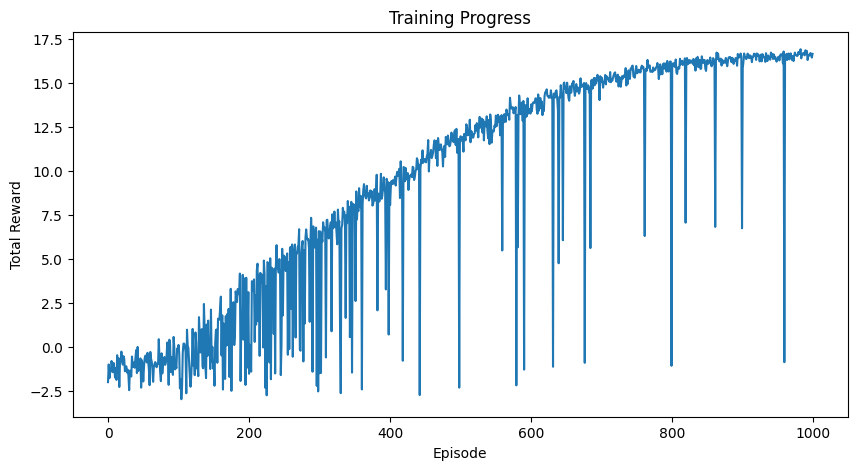

Test Reward: 16.61874172207405


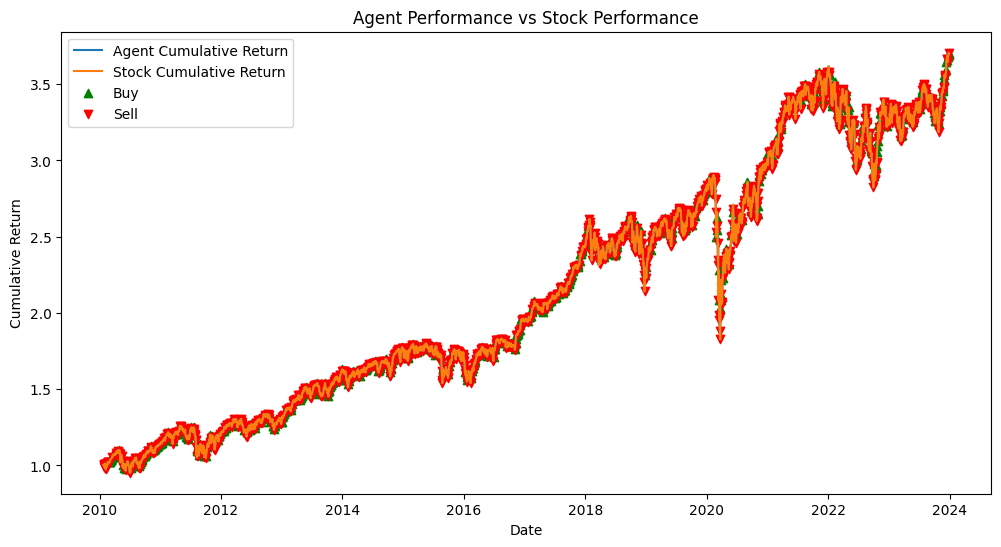

Agent Sharpe Ratio: 0.5822
Stock Sharpe Ratio: 0.5813
Agent Sortino Ratio: 0.8961
Stock Sortino Ratio: 0.8948
Agent Max Drawdown: -0.3709
Stock Max Drawdown: -0.3709


ValueError: operands could not be broadcast together with shapes (3508,) (3507,) 

In [ ]:
import gym
from gym import spaces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as web
from collections import deque
import random

class TradingEnv(gym.Env):
    def __init__(self, start_date, end_date, tc=0.05/100, ticker='^DJI'):
        self.start = start_date
        self.end = end_date
        self.tc = tc
        self.ticker = ticker

        self.action_space = spaces.Discrete(3)  # 0: sell, 1: hold, 2: buy
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)

        self.data_df = self.load_and_prepare_data()
        self.curr_index = 0
        self.data_len = self.data_df.shape[0]
        self.position = 0

    def step(self, action):
        done = False
        current_price = self.data_df.iloc[self.curr_index]['Close']
        next_price = self.data_df.iloc[self.curr_index + 1]['Close']

        # Calculate reward
        stock_return = (next_price - current_price) / current_price
        change_in_position = action - 1  # -1: sell, 0: hold, 1: buy
        cost = abs(change_in_position) * self.tc
        reward = change_in_position * stock_return - cost

        # Update position
        self.position += change_in_position

        if self.curr_index == self.data_len - 2:
            done = True
        self.curr_index += 1

        obs = self.get_state()
        info = {'date': self.data_df.index[self.curr_index], 'return': stock_return, 'position': self.position}

        return obs, reward, done, info

    def reset(self):
        self.curr_index = 0
        self.position = 0
        return self.get_state()

    def get_state(self):
        df = self.data_df
        i = self.curr_index
        state = [
            df.iloc[i]['Close'] / df.iloc[i-1]['Close'] - 1,  # Daily return
            df.iloc[i]['Volume'] / df.iloc[i-5:i]['Volume'].mean() - 1,  # Volume
            df.iloc[i]['Close'] / df.iloc[i-5:i]['Close'].mean() - 1,  # 5-day MA
            df.iloc[i]['Close'] / df.iloc[i-20:i]['Close'].mean() - 1,  # 20-day MA
            df.iloc[i]['RSI'],
            df.iloc[i]['MACD'],
            self.position
        ]
        return np.array(state)

    def load_and_prepare_data(self):
        df = web.DataReader(self.ticker, 'stooq', self.start, self.end)
        df = df.sort_index()
        df['RSI'] = self.compute_rsi(df['Close'])
        df['MACD'] = self.compute_macd(df['Close'])
        return df.dropna()

    @staticmethod
    def compute_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    @staticmethod
    def compute_macd(prices, fast=12, slow=26, signal=9):
        ema_fast = prices.ewm(span=fast, adjust=False).mean()
        ema_slow = prices.ewm(span=slow, adjust=False).mean()
        macd = ema_fast - ema_slow
        signal_line = macd.ewm(span=signal, adjust=False).mean()
        return macd - signal_line

    def get_stock_cumulative_return(self):
        return (self.data_df['Close'] / self.data_df['Close'].iloc[0]).to_dict()

class DoubleQLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.q_table1 = {}
        self.q_table2 = {}
        self.experience_replay = deque(maxlen=1000)

    def get_q_value(self, state, action, q_table):
        return q_table.get((state, action), 0.0)

    def choose_action(self, state):
        if np.random.uniform() < self.epsilon:
            return self.env.action_space.sample()
        else:
            q_values = [self.get_q_value(state, a, self.q_table1) + self.get_q_value(state, a, self.q_table2) for a in range(self.env.action_space.n)]
            return np.argmax(q_values)

    def update_q_tables(self, state, action, reward, next_state):
        self.experience_replay.append((state, action, reward, next_state))
        if len(self.experience_replay) >= 64:
            batch = random.sample(self.experience_replay, 64)
            for state, action, reward, next_state in batch:
                if np.random.random() < 0.5:
                    self.update_q_table(state, action, reward, next_state, self.q_table1, self.q_table2)
                else:
                    self.update_q_table(state, action, reward, next_state, self.q_table2, self.q_table1)

    def update_q_table(self, state, action, reward, next_state, q_table_update, q_table_select):
        best_next_action = max(range(self.env.action_space.n), key=lambda a: q_table_select.get((next_state, a), 0))
        td_target = reward + self.gamma * self.get_q_value(next_state, best_next_action, q_table_update)
        current_q = self.get_q_value(state, action, q_table_update)
        q_table_update[(state, action)] = current_q + self.alpha * (td_target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

def train_agent(env, agent, num_episodes=1000):
    episode_rewards = []
    for episode in range(num_episodes):
        state = tuple(env.reset())
        done = False
        total_reward = 0
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)
            next_state = tuple(next_state)
            agent.update_q_tables(state, action, reward, next_state)
            state = next_state
            total_reward += reward
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        if episode % 100 == 0:
            print(f"Episode {episode}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.2f}")
    return episode_rewards

def test_agent(env, agent):
    state = tuple(env.reset())
    done = False
    total_reward = 0
    actions_taken = []
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done, info = env.step(action)
        state = tuple(next_state)
        total_reward += reward
        actions_taken.append((info['date'], action, info['position'], info['return']))
    stock_cumulative_return = env.get_stock_cumulative_return()
    return total_reward, actions_taken, stock_cumulative_return

def calculate_sharpe_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    return np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)

def calculate_sortino_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    downside_returns = np.minimum(excess_returns, 0)
    return np.mean(excess_returns) / np.std(downside_returns) * np.sqrt(252)

def calculate_max_drawdown(cumulative_returns):
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns / peak) - 1
    return drawdown.min()

if __name__ == '__main__':
    env = TradingEnv(start_date='2010-01-01', end_date='2024-01-01')
    agent = DoubleQLearningAgent(env)

    # Training
    episode_rewards = train_agent(env, agent)

    # Plot training results
    plt.figure(figsize=(10, 5))
    plt.plot(episode_rewards)
    plt.title('Training Progress')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

    # Testing
    test_reward, actions, stock_cumulative_return = test_agent(env, agent)
    print(f"Test Reward: {test_reward}")

    # Plot test results
    df = pd.DataFrame(actions, columns=['Date', 'Action', 'Position', 'Return'])
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df['AgentCumulativeReturn'] = (1 + df['Return']).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['AgentCumulativeReturn'], label='Agent Cumulative Return')
    plt.plot(df.index, [stock_cumulative_return[date] for date in df.index], label='Stock Cumulative Return')
    buy_points = df[df['Action'] == 2].index
    sell_points = df[df['Action'] == 0].index
    plt.scatter(buy_points, df.loc[buy_points, 'AgentCumulativeReturn'], color='green', marker='^', label='Buy')
    plt.scatter(sell_points, df.loc[sell_points, 'AgentCumulativeReturn'], color='red', marker='v', label='Sell')
    plt.title('Agent Performance vs Stock Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.show()

    # Calculate risk-adjusted metrics
    agent_returns = df['Return'].values
    stock_returns = np.diff([stock_cumulative_return[date] for date in df.index]) / np.array([stock_cumulative_return[date] for date in df.index][:-1])

    agent_sharpe = calculate_sharpe_ratio(agent_returns)
    stock_sharpe = calculate_sharpe_ratio(stock_returns)

    agent_sortino = calculate_sortino_ratio(agent_returns)
    stock_sortino = calculate_sortino_ratio(stock_returns)

    agent_max_drawdown = calculate_max_drawdown(df['AgentCumulativeReturn'])
    stock_max_drawdown = calculate_max_drawdown(pd.Series(stock_cumulative_return).sort_index())

    print(f"Agent Sharpe Ratio: {agent_sharpe:.4f}")
    print(f"Stock Sharpe Ratio: {stock_sharpe:.4f}")
    print(f"Agent Sortino Ratio: {agent_sortino:.4f}")
    print(f"Stock Sortino Ratio: {stock_sortino:.4f}")
    print(f"Agent Max Drawdown: {agent_max_drawdown:.4f}")
    print(f"Stock Max Drawdown: {stock_max_drawdown:.4f}")



**Quantum RL**

Quantum variational circuit is used as a function approximator to estimate Q-values for each state-action pair. Circuit is constructed using ReUploadingPQC layer, which applies a parameterised quantum circuit with re-uploading of the input data at each layer. The input to quantum circuit is the state observation, and the output is the Q-values for each action.

**5 Qubits circuit**

In [ ]:
import gym
from gym.envs.registration import register
from gym import error, spaces, utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as web
import random
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq, sympy
from collections import deque
from cirq.contrib.svg import SVGCircuit
from functools import reduce

class TradingEnv(gym.Env):
    def __init__(self, start_date, end_date, tc=0.05/100, ticker='^DJI'):
        self.start = start_date
        self.end = end_date
        self.tc = tc
        self.ticker = ticker

        self.action_space = spaces.Discrete(3)  # Buy, Sell, Hold
        self.observation_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32)
        returns = self.load_dataset()
        self.data_df = self.create_features(returns)
        self.curr_index = 0
        self.data_len = self.data_df.shape[0]
        self.action = 0

    def step(self, action):
        done = False
        stock_return = self.extract_return(self.data_df, self.curr_index)
        change_in_position = np.abs(self.action - action)
        cost = change_in_position * self.tc
        reward = action * stock_return - cost

        if self.curr_index == self.data_len - 2:
            done = True
        self.curr_index += 1
        self.action = action

        obs = self.extract_state(self.data_df, self.curr_index).values

        info = {'date': self.data_df.index[self.curr_index], 'return': stock_return}

        return obs, reward, done, info

    def reset(self):
        self.curr_index = 0
        self.action = 0
        return self.extract_state(self.data_df, self.curr_index).values

    def render(self, mode='human'):
        pass

    def extract_return(self, df, i):
        return df.iloc[i]['Y']

    def extract_state(self, df, i):
        return df.iloc[i][['r%d' % i for i in range(5)]]

    def load_dataset(self):
        df = web.DataReader(self.ticker, 'stooq')
        mask = (self.start <= df.index) & (df.index <= self.end)
        df = df[mask]
        df = df.sort_values(by='Date')
        returns = df['Close'].pct_change()
        return returns

    def create_features(self, returns):
        dfs = []
        for i in range(5):
            dfs.append(returns.shift(i).rename('r%d' % i))
        dfs.append(returns.shift(-1).rename('Y'))
        df_net = pd.concat(dfs, axis=1)
        df_net = df_net.dropna()
        return df_net

register(
    id='trading-v0',
    entry_point=__name__ + ':TradingEnv',
    kwargs={
        'start_date': '2019-01-01',
        'end_date': '2024-01-10',
    }
)

def one_qubit_rotation(qubit, symbols):
    return [cirq.rx(symbols[0])(qubit), cirq.ry(symbols[1])(qubit), cirq.rz(symbols[2])(qubit)]

def entangling_layer(qubits):
    cz_ops = [cirq.CZ(q0, q1) for q0, q1 in zip(qubits, qubits[1:])]
    cz_ops += ([cirq.CZ(qubits[0], qubits[-1])] if len(qubits) != 2 else [])
    return cz_ops

def generate_circuit(qubits, n_layers):
    n_qubits = len(qubits)
    params = sympy.symbols(f'theta(0:{3*(n_layers+1)*n_qubits})')
    params = np.asarray(params).reshape((n_layers + 1, n_qubits, 3))
    inputs = sympy.symbols(f'x(0:{n_layers})' + f'_(0:{n_qubits})')
    inputs = np.asarray(inputs).reshape((n_layers, n_qubits))

    circuit = cirq.Circuit()
    for l in range(n_layers):
        circuit += cirq.Circuit(one_qubit_rotation(q, params[l, i]) for i, q in enumerate(qubits))
        circuit += entangling_layer(qubits)
        circuit += cirq.Circuit(cirq.rx(inputs[l, i])(q) for i, q in enumerate(qubits))

    circuit += cirq.Circuit(one_qubit_rotation(q, params[n_layers, i]) for i, q in enumerate(qubits))

    return circuit, list(params.flat), list(inputs.flat)

class ReUploadingPQC(tf.keras.layers.Layer):
    def __init__(self, qubits, n_layers, observables, activation="linear", name="re-uploading_PQC"):
        super(ReUploadingPQC, self).__init__(name=name)
        self.n_layers = n_layers
        self.n_qubits = len(qubits)

        circuit, theta_symbols, input_symbols = generate_circuit(qubits, n_layers)

        theta_init = tf.random_uniform_initializer(minval=0.0, maxval=np.pi)
        self.theta = tf.Variable(
            initial_value=theta_init(shape=(1, len(theta_symbols)), dtype="float32"),
            trainable=True, name="thetas"
        )

        lmbd_init = tf.ones(shape=(self.n_qubits * self.n_layers,))
        self.lmbd = tf.Variable(
            initial_value=lmbd_init, dtype="float32", trainable=True, name="lambdas"
        )

        symbols = [str(symb) for symb in theta_symbols + input_symbols]
        self.indices = tf.constant([symbols.index(a) for a in sorted(symbols)])

        self.activation = activation
        self.empty_circuit = tfq.convert_to_tensor([cirq.Circuit()])
        self.computation_layer = tfq.layers.ControlledPQC(circuit, observables)

    def call(self, inputs):
        batch_dim = tf.gather(tf.shape(inputs[0]), 0)
        tiled_up_circuits = tf.repeat(self.empty_circuit, repeats=batch_dim)
        tiled_up_thetas = tf.tile(self.theta, multiples=[batch_dim, 1])
        tiled_up_inputs = tf.tile(inputs[0], multiples=[1, self.n_layers])
        scaled_inputs = tf.einsum("i,ji->ji", self.lmbd, tiled_up_inputs)
        squashed_inputs = tf.keras.layers.Activation(self.activation)(scaled_inputs)

        joined_vars = tf.concat([tiled_up_thetas, squashed_inputs], axis=1)
        joined_vars = tf.gather(joined_vars, self.indices, axis=1)

        return self.computation_layer([tiled_up_circuits, joined_vars])

class Rescaling(tf.keras.layers.Layer):
    def __init__(self, input_dim):
        super(Rescaling, self).__init__()
        self.input_dim = input_dim
        self.w = tf.Variable(
            initial_value=tf.ones(shape=(1, input_dim)), dtype="float32",
            trainable=True, name="obs-weights")

    def call(self, inputs):
        return tf.math.multiply((inputs + 1) / 2, tf.repeat(self.w, repeats=tf.shape(inputs)[0], axis=0))

def generate_model_Qlearning(qubits, n_layers, n_actions, observables, target):
    input_tensor = tf.keras.Input(shape=(len(qubits),), dtype=tf.dtypes.float32, name='input')
    re_uploading_pqc = ReUploadingPQC(qubits, n_layers, observables, activation='tanh')([input_tensor])
    process = tf.keras.Sequential([Rescaling(len(observables))], name=target * "Target" + "Q-values")
    Q_values = process(re_uploading_pqc)
    model = tf.keras.Model(inputs=[input_tensor], outputs=Q_values)

    return model

def interact_env(state, model, epsilon, n_actions, env):
    coin = np.random.random()
    if coin > epsilon:
        state_tensor = tf.expand_dims(state, axis=0)  # Add batch dimension
        q_vals = model([state_tensor])
        action = int(tf.argmax(q_vals[0]).numpy())
    else:
        action = np.random.choice(n_actions)

    next_state, reward, done, _ = env.step(action)

    interaction = {'state': state, 'action': action, 'next_state': next_state,
                   'reward': reward, 'done': np.float32(done)}

    return interaction

@tf.function
def Q_learning_update(states, actions, rewards, next_states, done, model, gamma, n_actions):
    states = tf.convert_to_tensor(states)
    actions = tf.convert_to_tensor(actions)
    rewards = tf.convert_to_tensor(rewards)
    next_states = tf.convert_to_tensor(next_states)
    done = tf.convert_to_tensor(done)

    future_rewards = model_target([next_states])
    target_q_values = rewards + (gamma * tf.reduce_max(future_rewards, axis=1)
                                                   * (1.0 - done))
    masks = tf.one_hot(actions, n_actions)

    with tf.GradientTape() as tape:
        tape.watch(model.trainable_variables)
        q_values = model([states])
        q_values_masked = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
        loss = tf.keras.losses.Huber()(target_q_values, q_values_masked)

    grads = tape.gradient(loss, model.trainable_variables)
    for optimizer, w in zip([optimizer_in, optimizer_var, optimizer_out], [w_in, w_var, w_out]):
        optimizer.apply_gradients([(grads[w], model.trainable_variables[w])])

env_name = 'trading-v0'
env = gym.make(env_name)

n_actions = 3  # Buy, Sell, Hold
n_qubits = 5
n_layers = 5

qubits = cirq.GridQubit.rect(1, n_qubits)
ops = [cirq.Z(q) for q in qubits]
observables = [ops[0]*ops[1], ops[2]*ops[3], ops[4]]

model = generate_model_Qlearning(qubits, n_layers, n_actions, observables, False)
model_target = generate_model_Qlearning(qubits, n_layers, n_actions, observables, True)

model_target.set_weights(model.get_weights())

gamma = 0.99
n_episodes = 500
max_memory_length = 1000
replay_memory = deque(maxlen=max_memory_length)

epsilon = 1.0
epsilon_min = 0.01
decay_epsilon = 0.995
batch_size = 32
steps_per_update = 4
steps_per_target_update = 100

optimizer_in = tf.keras.optimizers.Adam(learning_rate=0.001, amsgrad=True)
optimizer_var = tf.keras.optimizers.Adam(learning_rate=0.001, amsgrad=True)
optimizer_out = tf.keras.optimizers.Adam(learning_rate=0.1, amsgrad=True)

w_in, w_var, w_out = 1, 0, 2

episode_reward_history = []
step_count = 0
for episode in range(n_episodes):
    episode_reward = 0
    state = env.reset()

    while True:
        interaction = interact_env(state, model, epsilon, n_actions, env)

        replay_memory.append(interaction)

        state = interaction['next_state']
        episode_reward += interaction['reward']
        step_count += 1

        if step_count % steps_per_update == 0 and len(replay_memory) >= batch_size:
            training_batch = random.sample(replay_memory, batch_size)
            Q_learning_update(np.asarray([x['state'] for x in training_batch]),
                              np.asarray([x['action'] for x in training_batch]),
                              np.asarray([x['reward'] for x in training_batch], dtype=np.float32),
                              np.asarray([x['next_state'] for x in training_batch]),
                              np.asarray([x['done'] for x in training_batch], dtype=np.float32),
                              model, gamma, n_actions)

        if step_count % steps_per_target_update == 0:
            model_target.set_weights(model.get_weights())

        if interaction['done']:
            break

    epsilon = max(epsilon * decay_epsilon, epsilon_min)
    episode_reward_history.append(episode_reward)
    if (episode + 1) % 10 == 0:
        avg_rewards = np.mean(episode_reward_history[-10:])
        print(f"Episode {episode + 1}/{n_episodes}, average last 10 rewards {avg_rewards:.2f}")
        if avg_rewards >= 200.0:
            break

plt.figure(figsize=(10, 5))
plt.plot(episode_reward_history)
plt.xlabel('Episode')
plt.ylabel('Collected rewards')
plt.show()


**Updated quantum code**


In [ ]:
import gym
from gym.envs.registration import register
from gym import error, spaces, utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import random
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq, sympy
from collections import deque
from cirq.contrib.svg import SVGCircuit
from functools import reduce

# Trading Environment
class TradingEnv(gym.Env):
    def __init__(self, start_date, end_date, tc=0.05/100, ticker='^DJI'):
        self.start = start_date
        self.end = end_date
        self.tc = tc
        self.ticker = ticker

        self.action_space = spaces.Discrete(3)  # Buy, Sell, Hold
        self.observation_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32)
        returns = self.load_dataset()
        self.data_df = self.create_features(returns)
        self.curr_index = 0
        self.data_len = self.data_df.shape[0]
        self.action = 0

    def step(self, action):
        done = False
        stock_return = self.extract_return(self.data_df, self.curr_index)
        change_in_position = np.abs(self.action - action)
        cost = change_in_position * self.tc
        reward = action * stock_return - cost

        if self.curr_index == self.data_len - 2:
            done = True
        self.curr_index += 1
        self.action = action

        obs = self.extract_state(self.data_df, self.curr_index).values

        info = {'date': self.data_df.index[self.curr_index], 'return': stock_return}

        return obs, reward, done, info

    def reset(self):
        self.curr_index = 0
        self.action = 0
        return self.extract_state(self.data_df, self.curr_index).values

    def render(self, mode='human'):
        pass

    def extract_return(self, df, i):
        return df.iloc[i]['Y']

    def extract_state(self, df, i):
        return df.iloc[i][['r%d' % i for i in range(5)]]

    def load_dataset(self):
        df = yf.download(self.ticker, start=self.start, end=self.end)
        df = df.sort_values(by='Date')
        returns = df['Close'].pct_change()
        return returns

    def create_features(self, returns):
        dfs = []
        for i in range(5):
            dfs.append(returns.shift(i).rename('r%d' % i))
        dfs.append(returns.shift(-1).rename('Y'))
        df_net = pd.concat(dfs, axis=1)
        df_net = df_net.dropna()
        return df_net

register(
    id='trading-v0',
    entry_point=__name__ + ':TradingEnv',
    kwargs={
        'start_date': '2019-01-01',
        'end_date': '2024-01-10',
    }
)

def one_qubit_rotation(qubit, symbols):
    return [cirq.rx(symbols[0])(qubit), cirq.ry(symbols[1])(qubit), cirq.rz(symbols[2])(qubit)]

def entangling_layer(qubits):
    cz_ops = [cirq.CZ(q0, q1) for q0, q1 in zip(qubits, qubits[1:])]
    cz_ops += ([cirq.CZ(qubits[0], qubits[-1])] if len(qubits) != 2 else [])
    return cz_ops

def generate_circuit(qubits, n_layers):
    n_qubits = len(qubits)
    params = sympy.symbols(f'theta(0:{3*(n_layers+1)*n_qubits})')
    params = np.asarray(params).reshape((n_layers + 1, n_qubits, 3))
    inputs = sympy.symbols(f'x(0:{n_layers})' + f'_(0:{n_qubits})')
    inputs = np.asarray(inputs).reshape((n_layers, n_qubits))

    circuit = cirq.Circuit()
    for l in range(n_layers):
        circuit += cirq.Circuit(one_qubit_rotation(q, params[l, i]) for i, q in enumerate(qubits))
        circuit += entangling_layer(qubits)
        circuit += cirq.Circuit(cirq.rx(inputs[l, i])(q) for i, q in enumerate(qubits))

    circuit += cirq.Circuit(one_qubit_rotation(q, params[n_layers, i]) for i, q in enumerate(qubits))

    return circuit, list(params.flat), list(inputs.flat)

class ReUploadingPQC(tf.keras.layers.Layer):
    def __init__(self, qubits, n_layers, observables, activation="linear", name="re-uploading_PQC"):
        super(ReUploadingPQC, self).__init__(name=name)
        self.n_layers = n_layers
        self.n_qubits = len(qubits)

        circuit, theta_symbols, input_symbols = generate_circuit(qubits, n_layers)

        theta_init = tf.random_uniform_initializer(minval=0.0, maxval=np.pi)
        self.theta = tf.Variable(
            initial_value=theta_init(shape=(1, len(theta_symbols)), dtype="float32"),
            trainable=True, name="thetas"
        )

        lmbd_init = tf.ones(shape=(self.n_qubits * self.n_layers,))
        self.lmbd = tf.Variable(
            initial_value=lmbd_init, dtype="float32", trainable=True, name="lambdas"
        )

        symbols = [str(symb) for symb in theta_symbols + input_symbols]
        self.indices = tf.constant([symbols.index(a) for a in sorted(symbols)])

        self.activation = activation
        self.empty_circuit = tfq.convert_to_tensor([cirq.Circuit()])
        self.computation_layer = tfq.layers.ControlledPQC(circuit, observables)

    def call(self, inputs):
        batch_dim = tf.gather(tf.shape(inputs[0]), 0)
        tiled_up_circuits = tf.repeat(self.empty_circuit, repeats=batch_dim)
        tiled_up_thetas = tf.tile(self.theta, multiples=[batch_dim, 1])
        tiled_up_inputs = tf.tile(inputs[0], multiples=[1, self.n_layers])
        scaled_inputs = tf.einsum("i,ji->ji", self.lmbd, tiled_up_inputs)
        squashed_inputs = tf.keras.layers.Activation(self.activation)(scaled_inputs)

        joined_vars = tf.concat([tiled_up_thetas, squashed_inputs], axis=1)
        joined_vars = tf.gather(joined_vars, self.indices, axis=1)

        return self.computation_layer([tiled_up_circuits, joined_vars])

class Rescaling(tf.keras.layers.Layer):
    def __init__(self, input_dim):
        super(Rescaling, self).__init__()
        self.input_dim = input_dim
        self.w = tf.Variable(
            initial_value=tf.ones(shape=(1, input_dim)), dtype="float32",
            trainable=True, name="obs-weights")

    def call(self, inputs):
        return tf.math.multiply((inputs + 1) / 2, tf.repeat(self.w, repeats=tf.shape(inputs)[0], axis=0))

def generate_model_Qlearning(qubits, n_layers, n_actions, observables, target):
    input_tensor = tf.keras.Input(shape=(len(qubits),), dtype=tf.dtypes.float32, name='input')
    re_uploading_pqc = ReUploadingPQC(qubits, n_layers, observables, activation='tanh')([input_tensor])
    process = tf.keras.Sequential([Rescaling(len(observables))], name=target * "Target" + "Q-values")
    Q_values = process(re_uploading_pqc)
    model = tf.keras.Model(inputs=[input_tensor], outputs=Q_values)

    return model

def interact_env(state, model, epsilon, n_actions, env):
    coin = np.random.random()
    if coin > epsilon:
        state_tensor = tf.expand_dims(state, axis=0)  # Add batch dimension
        q_vals = model([state_tensor])
        action = int(tf.argmax(q_vals[0]).numpy())
    else:
        action = np.random.choice(n_actions)

    next_state, reward, done, _ = env.step(action)

    interaction = {'state': state, 'action': action, 'next_state': next_state,
                   'reward': reward, 'done': np.float32(done)}

    return interaction

@tf.function
def Q_learning_update(states, actions, rewards, next_states, done, model, gamma, n_actions):
    states = tf.convert_to_tensor(states)
    actions = tf.convert_to_tensor(actions)
    rewards = tf.convert_to_tensor(rewards)
    next_states = tf.convert_to_tensor(next_states)
    done = tf.convert_to_tensor(done)

    future_rewards = model_target([next_states])
    target_q_values = rewards + (gamma * tf.reduce_max(future_rewards, axis=1)
                                                   * (1.0 - done))
    masks = tf.one_hot(actions, n_actions)

    with tf.GradientTape() as tape:
        tape.watch(model.trainable_variables)
        q_values = model([states])
        q_values_masked = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
        loss = tf.keras.losses.Huber()(target_q_values, q_values_masked)

    grads = tape.gradient(loss, model.trainable_variables)
    for optimizer, w in zip([optimizer_in, optimizer_var, optimizer_out], [w_in, w_var, w_out]):
        optimizer.apply_gradients([(grads[w], model.trainable_variables[w])])

env_name = 'trading-v0'
env = gym.make(env_name)

n_actions = 3  # Buy, Sell, Hold
n_qubits = 5
n_layers = 5

qubits = cirq.GridQubit.rect(1, n_qubits)
ops = [cirq.Z(q) for q in qubits]
observables = [ops[0]*ops[1], ops[2]*ops[3], ops[4]]

model = generate_model_Qlearning(qubits, n_layers, n_actions, observables, False)
model_target = generate_model_Qlearning(qubits, n_layers, n_actions, observables, True)

model_target.set_weights(model.get_weights())

gamma = 0.99
n_episodes = 500
max_memory_length = 1000
replay_memory = deque(maxlen=max_memory_length)

epsilon = 1.0
epsilon_min = 0.01
decay_epsilon = 0.995
batch_size = 32
steps_per_update = 4
steps_per_target_update = 100

optimizer_in = tf.keras.optimizers.Adam(learning_rate=0.001, amsgrad=True)
optimizer_var = tf.keras.optimizers.Adam(learning_rate=0.001, amsgrad=True)
optimizer_out = tf.keras.optimizers.Adam(learning_rate=0.1, amsgrad=True)

w_in, w_var, w_out = 1, 0, 2

episode_reward_history = []
step_count = 0
for episode in range(n_episodes):
    episode_reward = 0
    state = env.reset()

    while True:
        interaction = interact_env(state, model, epsilon, n_actions, env)

        replay_memory.append(interaction)

        state = interaction['next_state']
        episode_reward += interaction['reward']
        step_count += 1

        if step_count % steps_per_update == 0 and len(replay_memory) >= batch_size:
            training_batch = random.sample(replay_memory, batch_size)
            Q_learning_update(np.asarray([x['state'] for x in training_batch]),
                              np.asarray([x['action'] for x in training_batch]),
                              np.asarray([x['reward'] for x in training_batch], dtype=np.float32),
                              np.asarray([x['next_state'] for x in training_batch]),
                              np.asarray([x['done'] for x in training_batch], dtype=np.float32),
                              model, gamma, n_actions)

        if step_count % steps_per_target_update == 0:
            model_target.set_weights(model.get_weights())

        if interaction['done']:
            break

    epsilon = max(epsilon * decay_epsilon, epsilon_min)
    episode_reward_history.append(episode_reward)
    if (episode + 1) % 10 == 0:
        avg_rewards = np.mean(episode_reward_history[-10:])
        print(f"Episode {episode + 1}/{n_episodes}, average last 10 rewards {avg_rewards:.2f}")
        if avg_rewards >= 200.0:
            break

plt.figure(figsize=(10, 5))
plt.plot(episode_reward_history)
plt.xlabel('Episode')
plt.ylabel('Collected rewards')
plt.show()


[*********************100%%**********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env

Episode 10/500, average last 10 rewards 0.01
Episode 20/500, average last 10 rewards 0.02
Episode 30/500, average last 10 rewards 0.02
Episode 40/500, average last 10 rewards 0.13
Episode 50/500, average last 10 rewards 0.23
Episode 60/500, average last 10 rewards 0.25
Episode 70/500, average last 10 rewards 0.25
Episode 80/500, average last 10 rewards 0.26
Episode 90/500, average last 10 rewards 0.25
Episode 100/500, average last 10 rewards 0.38
Episode 110/500, average last 10 rewards 0.49
Episode 120/500, average last 10 rewards 0.41
Episode 130/500, average last 10 rewards 0.28
Episode 140/500, average last 10 rewards 0.25
Episode 150/500, average last 10 rewards 0.41
Episode 160/500, average last 10 rewards 0.47
Episode 170/500, average last 10 rewards 0.54
